# Лабораторная работа 2
## Neural ODE для прогнозирования AirPassengers
Исследуем непрерывную динамику скрытого состояния, прогноз на 12 месяцев и
устойчивость к повреждению истории наблюдений. 

## Данные
Классический ряд Box–Jenkins AirPassengers: месячный международный
пассажиропоток в тысячах, январь 1949 — декабрь 1960, 144 наблюдения.
[Документация R](https://stat.ethz.ch/R-manual/R-devel/library/datasets/html/AirPassengers.html),
[CSV](https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/AirPassengers.csv).
[Neural ODE, Chen et al., 2018](https://proceedings.neurips.cc/paper/2018/hash/69386f6bb1dfed68692a24c8686939b9-Abstract.html).


PyTorch: 2.14.0 | CPU | seed: 42
{
  "observations": 144,
  "missing": 0,
  "duplicate_rows": 0,
  "duplicate_times": 0,
  "min": 104.0,
  "max": 622.0,
  "mean": 280.2986145019531,
  "std": 119.54904174804688,
  "sha256": "bdb98adbd418a6de6842a742e0602f363c3b841c26677e7e61a1e055e9509bd8"
}
Подозрительные годовые изменения (не удаляем автоматически): []


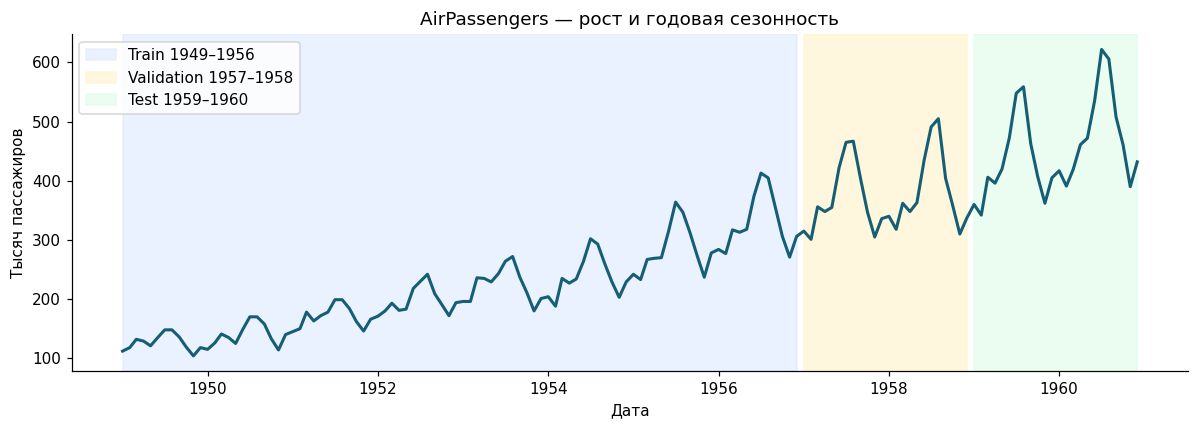

In [3]:
from pathlib import Path
import copy, hashlib, json, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch
from torch import nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)
ROOT = Path.cwd()
FIG = ROOT / 'figures'
FIG.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.family': 'DejaVu Sans'})

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG / f'{name}.png', dpi=170, bbox_inches='tight')
    plt.show()

SOURCE = 'https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/AirPassengers.csv'
path = ROOT / 'data' / 'AirPassengers.csv'
if not path.exists():
    path.parent.mkdir(exist_ok=True)
    pd.read_csv(SOURCE).to_csv(path, index=False)
raw = pd.read_csv(path)
dates = pd.date_range('1949-01-01', periods=len(raw), freq='MS')
values = raw['value'].to_numpy(dtype=np.float32)

quality = {'observations': len(raw), 'missing': int(raw.isna().sum().sum()),
           'duplicate_rows': int(raw.duplicated().sum()),
           'duplicate_times': int(raw['time'].duplicated().sum()),
           'min': float(values.min()), 'max': float(values.max()),
           'mean': float(values.mean()), 'std': float(values.std()),
           'sha256': hashlib.sha256(path.read_bytes()).hexdigest()}
print('PyTorch:', torch.__version__, '| CPU | seed:', SEED)
print(json.dumps(quality, indent=2))

yoy = np.log(values[12:]) - np.log(values[:-12])
mad = np.median(np.abs(yoy - np.median(yoy)))
flags = np.abs(yoy - np.median(yoy)) > 4 * 1.4826 * mad
print('Подозрительные годовые изменения (не удаляем автоматически):', dates[12:][flags].strftime('%Y-%m').tolist())

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(dates, values, color='#155e75', lw=2)
for a,b,c,label in [(0,95,'#dbeafe','Train 1949–1956'),(96,119,'#fef3c7','Validation 1957–1958'),(120,143,'#dcfce7','Test 1959–1960')]:
    ax.axvspan(dates[a], dates[b], alpha=.6, color=c, label=label)
ax.set(title='AirPassengers — рост и годовая сезонность', ylabel='Тысяч пассажиров', xlabel='Дата')
ax.legend()
savefig('01_dataset')

## Постановка и защита от утечки будущего
Вход — последние 24 месяца $x\in\mathbb{R}^{24}$ и известная календарная фаза.
Цель — следующие 12 месяцев $y\in\mathbb{R}^{12}$. Прогноз строится целиком
из начального состояния: истинные будущие значения не подаются внутрь решателя.

Train: 1949–1956, validation: 1957–1958, test: 1959–1960. Окно включается
в часть, только если **все 12 целевых месяцев** принадлежат ей. История может
начинаться раньше границы. При сдвиге точки прогноза доступны уже наблюдённые
месяцы; это rolling-origin оценка, а не единственный прогноз на два года.
Перекрывающиеся окна зависимы: число окон не равно числу независимых экспериментов.

$z=(\log y-\mu_{train})/\sigma_{train}$; статистики оцениваются только на train.
Логарифм уменьшает различие амплитуд при росте уровня. Прогноз обратно
преобразуется экспонентой без поправки на смещение; MSE в log-шкале не
эквивалентна MSE в исходных единицах. Повторяющиеся значения пассажиропотока
не являются дубликатами объектов с разными датами. Календарь регулярный;
преимуществ на нерегулярных наблюдениях этот эксперимент не проверяет.

In [6]:
L, H = 24, 12
mu, sigma = float(np.log(values[:96]).mean()), float(np.log(values[:96]).std())
z = (np.log(values) - mu) / sigma

def windows(start, stop):
    origins = np.arange(max(L, start), stop-H+1)
    x = torch.tensor(np.stack([z[o-L:o] for o in origins]), dtype=torch.float32)
    y = torch.tensor(np.stack([z[o:o+H] for o in origins]), dtype=torch.float32)
    phase = torch.tensor((origins-1)%12/12, dtype=torch.float32)
    return x, y, phase, origins

parts = {'train': windows(0,96), 'validation': windows(96,120), 'test': windows(120,144)}
for name,(x,y,p,o) in parts.items():
    print(f'{name}: x={tuple(x.shape)}, y={tuple(y.shape)}, первые цели {dates[o[0]]:%Y-%m}, последние {dates[o[-1]+H-1]:%Y-%m}')
assert all((o[:,None]+np.arange(H) < end).all() and (o>=start).all()
           for (_,_,_,o),(start,end) in zip(parts.values(), [(24,96),(96,120),(120,144)]))

def inverse(a):
    if isinstance(a, torch.Tensor): a = a.detach().cpu().numpy()
    return np.exp(a*sigma+mu)

train: x=(61, 24), y=(61, 12), первые цели 1951-01, последние 1956-12
validation: x=(13, 24), y=(13, 12), первые цели 1957-01, последние 1958-12
test: x=(13, 24), y=(13, 12), первые цели 1959-01, последние 1960-12


## Математическая идея и схема
Сеть задаёт производную скрытого состояния, а не сразу 12 выходных значений:

$$h(0)=E_\phi(z_{o-24:o}-z_{o-1})\in\mathbb{R}^{12},\quad
\frac{dh(t)}{dt}=f_\theta(h(t),c(t)),\quad
c(t)=(\sin 2\pi(q+t),\cos 2\pi(q+t)).$$
$$\widehat z_{o+k-1}=z_{o-1}+w^\top[h(k/12)-h(0)],\quad k=1,\dots,12.$$

Схема: **24 наблюдения → log-нормализация → центрирование по последнему
наблюдению → encoder 24→32→12 → ODE 12→32→12 → линейное чтение в 12 моментах → exp**.
Последнее наблюдение служит опорным уровнем. Его вычитание помогает переносить
динамику на другой уровень ряда. Годовая периодичность явно внесена календарём,
а не целиком обнаружена сетью. Она известна до просмотра test.

Решатель RK4 с шагом $\Delta=1/12$ года:
$$k_1=f(t,h),\ k_2=f(t+\Delta/2,h+\Delta k_1/2),\
k_3=f(t+\Delta/2,h+\Delta k_2/2),\ k_4=f(t+\Delta,h+\Delta k_3),$$
$$h_{next}=h+\Delta(k_1+2k_2+2k_3+k_4)/6.$$
Обучение: $\mathcal L=\frac1{NH}\sum(\hat z-z)^2$, Adam, lr=0.003,
weight decay=0.0001, полный batch из train-окон, 500 эпох, clip grad norm=1.

**Индуктивная гипотеза:** единое гладкое векторное поле описывает изменение скрытых
признаков на всём горизонте. Время ODE соответствует будущему времени в годах;
$q$ — фаза последнего наблюдённого месяца. Координаты состояния обучаемые,
без заранее заданного физического смысла. Градиенты проходят через RK4 с помощью
обычного autograd; adjoint-метод не используется. Эпоха выбирается по validation MSE.

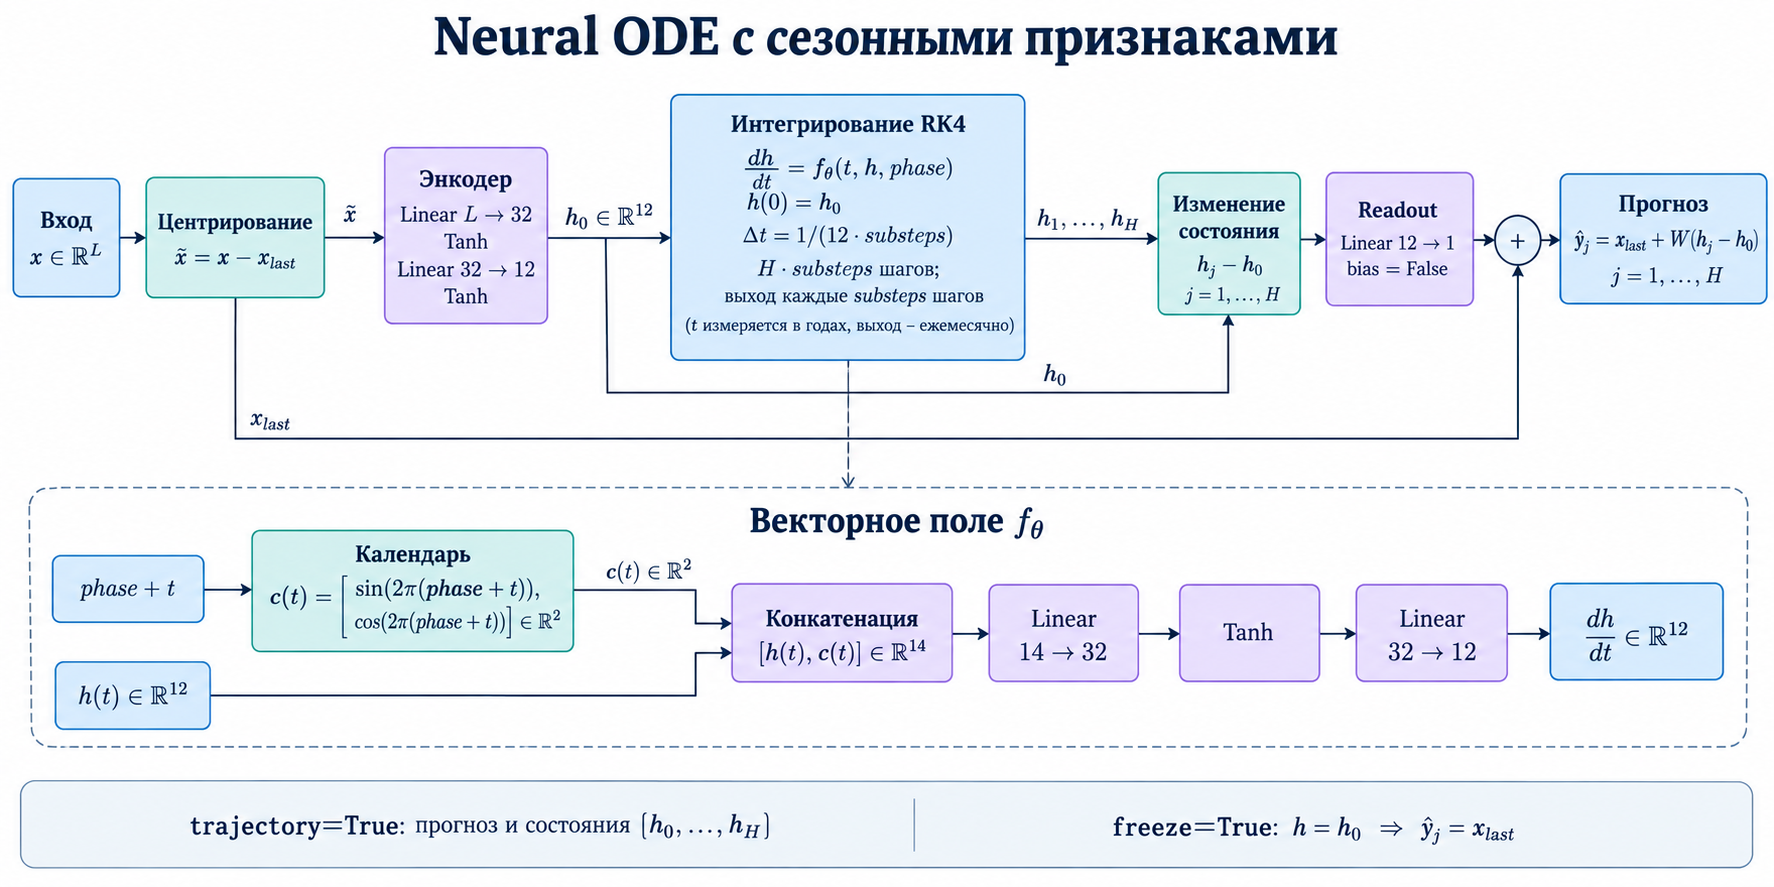

На схеме вход $x$ и выход сети обозначают нормализованные логарифмы. Для получения
тысяч пассажиров требуется обратное преобразование $\exp(\mu+\sigma\widehat z)$.


NeuralODE(
  (encoder): Sequential(
    (0): Linear(in_features=24, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=12, bias=True)
    (3): Tanh()
  )
  (field): Sequential(
    (0): Linear(in_features=14, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=12, bias=True)
  )
  (readout): Linear(in_features=12, out_features=1, bias=False)
)
Параметров: 2084
epoch 1: train MSE=0.32611; validation MSE=0.39139
epoch 100: train MSE=0.05658; validation MSE=0.11117
epoch 200: train MSE=0.04644; validation MSE=0.10723
epoch 300: train MSE=0.03740; validation MSE=0.10226
epoch 400: train MSE=0.02786; validation MSE=0.09716
epoch 500: train MSE=0.02148; validation MSE=0.09400
Лучшая эпоха: 436 | секунд: 7.9


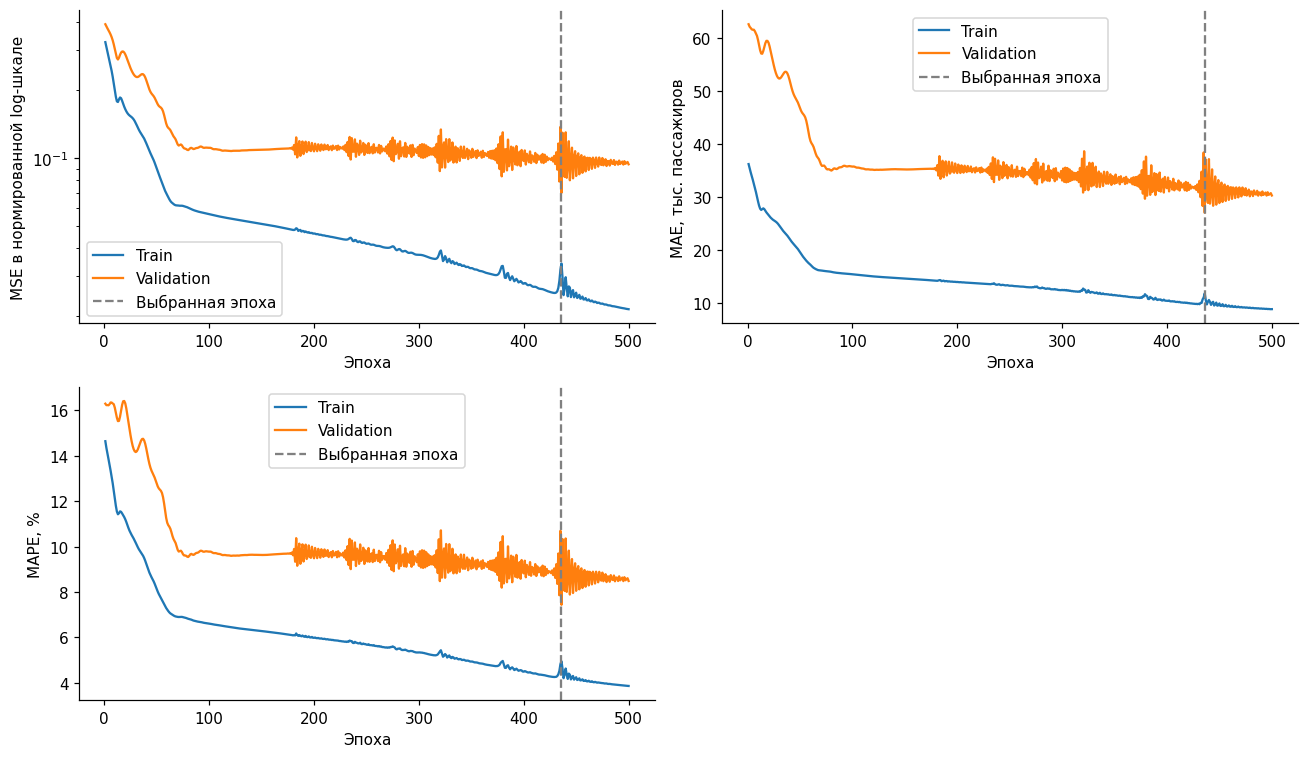

In [7]:
class NeuralODE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(L,32), nn.Tanh(), nn.Linear(32,12), nn.Tanh())
        self.field = nn.Sequential(nn.Linear(14,32), nn.Tanh(), nn.Linear(32,12))
        self.readout = nn.Linear(12,1,bias=False)

    def f(self, t, h, phase):
        angle = 2*torch.pi*(phase+t)
        calendar = torch.stack([angle.sin(),angle.cos()],dim=1)
        return self.field(torch.cat([h,calendar],dim=1))

    def forward(self,x,phase,substeps=1,trajectory=False,freeze=False):
        h0 = self.encoder(x-x[:,-1:])
        h = h0
        states, outputs = [h0], []
        dt = 1/(12*substeps)
        for k in range(H*substeps):
            t = k*dt
            if not freeze:
                a = self.f(t,h,phase)
                b = self.f(t+dt/2,h+dt*a/2,phase)
                c = self.f(t+dt/2,h+dt*b/2,phase)
                d = self.f(t+dt,h+dt*c,phase)
                h = h+dt*(a+2*b+2*c+d)/6
            if (k+1)%substeps == 0:
                states.append(h)
                outputs.append(x[:,-1]+self.readout(h-h0).squeeze(-1))
        prediction = torch.stack(outputs,dim=1)
        return (prediction,torch.stack(states,dim=1)) if trajectory else prediction

model = NeuralODE()
print(model)
print('Параметров:', sum(p.numel() for p in model.parameters()))

optimizer = torch.optim.Adam(model.parameters(),lr=.003,weight_decay=1e-4)
xt,yt,pt,_ = parts['train']
xv,yv,pv,_ = parts['validation']
history, best, best_state = [], float('inf'), None
started = time.time()


for epoch in range(1,501):
    model.train()
    optimizer.zero_grad()
    loss = (model(xt,pt)-yt).square().mean()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(),1.)
    optimizer.step()

    model.eval()
    with torch.no_grad():
        train_pred = inverse(model(xt,pt))
        train_true = inverse(yt)
        val_pred = inverse(model(xv,pv))
        val_true = inverse(yv)
        train_loss = (model(xt,pt)-yt).square().mean().item()
        val_loss = (model(xv,pv)-yv).square().mean().item()
        train_mae = float(np.abs(train_pred-train_true).mean())
        val_mae = float(np.abs(val_pred-val_true).mean())
        train_mape = float((np.abs(train_pred-train_true)/train_true).mean()*100)
        val_mape = float((np.abs(val_pred-val_true)/val_true).mean()*100)
    history.append({'epoch':epoch,'train_mse':train_loss,'validation_mse':val_loss,
                    'train_mae':train_mae,'validation_mae':val_mae,
                    'train_mape':train_mape,'validation_mape':val_mape})
    if val_loss < best:
        best, best_epoch = val_loss, epoch
        best_state = copy.deepcopy(model.state_dict())
    if epoch == 1 or epoch%100 == 0:
        print(f'epoch {epoch}: train MSE={train_loss:.5f}; validation MSE={val_loss:.5f}')
model.load_state_dict(best_state)
model.eval()
print('Лучшая эпоха:', best_epoch, '| секунд:', round(time.time()-started,1))


history = pd.DataFrame(history)
fig, axes = plt.subplots(2,2,figsize=(12,7))
axes[0,0].plot(history.epoch,history.train_mse,label='Train')
axes[0,0].plot(history.epoch,history.validation_mse,label='Validation')
axes[0,0].axvline(best_epoch,color='gray',ls='--',label='Выбранная эпоха')
axes[0,0].set(yscale='log',xlabel='Эпоха',ylabel='MSE в нормированной log-шкале')
axes[0,0].legend()
axes[0,1].plot(history.epoch,history.train_mae,label='Train')
axes[0,1].plot(history.epoch,history.validation_mae,label='Validation')
axes[0,1].axvline(best_epoch,color='gray',ls='--',label='Выбранная эпоха')
axes[0,1].set(xlabel='Эпоха',ylabel='MAE, тыс. пассажиров')
axes[0,1].legend()
axes[1,0].plot(history.epoch,history.train_mape,label='Train')
axes[1,0].plot(history.epoch,history.validation_mape,label='Validation')
axes[1,0].axvline(best_epoch,color='gray',ls='--',label='Выбранная эпоха')
axes[1,0].set(xlabel='Эпоха',ylabel='MAPE, %')
axes[1,0].legend()
axes[1,1].axis('off')
fig.tight_layout()
savefig('02_learning')

## Базовая оценка и контрольные прогнозы
### Метрики
1) MAE измеряются в тысячах пассажиров
2) RMSE измеряются в тысячах пассажиров 
3) MAPE — в процентах.

Метрики усредняются по всем парам «точка прогноза, горизонт»

Сравниваем Neural ODE с последним значением, сезонным повтором прошлого года
и сезонным повтором с ростом. Последний baseline умножает прошлый год на
отношение средних последних и предпоследних 12 месяцев истории.

     split      model    MAE   RMSE  MAPE_pct
     train Neural ODE 11.901 14.884     4.947
validation Neural ODE 27.095 33.428     7.435
      test Neural ODE 34.599 44.940     7.785
Пять лучших окон (по MAE):
  1959-10: MAE=22.90 тыс.
  1959-03: MAE=23.47 тыс.
  1959-11: MAE=24.13 тыс.
  1959-01: MAE=25.08 тыс.
  1959-09: MAE=25.82 тыс.
Пять худших окон (по MAE):
  1959-05: MAE=81.63 тыс.
  1959-04: MAE=53.58 тыс.
  1959-12: MAE=40.35 тыс.
  1959-06: MAE=33.90 тыс.
  1959-07: MAE=32.97 тыс.


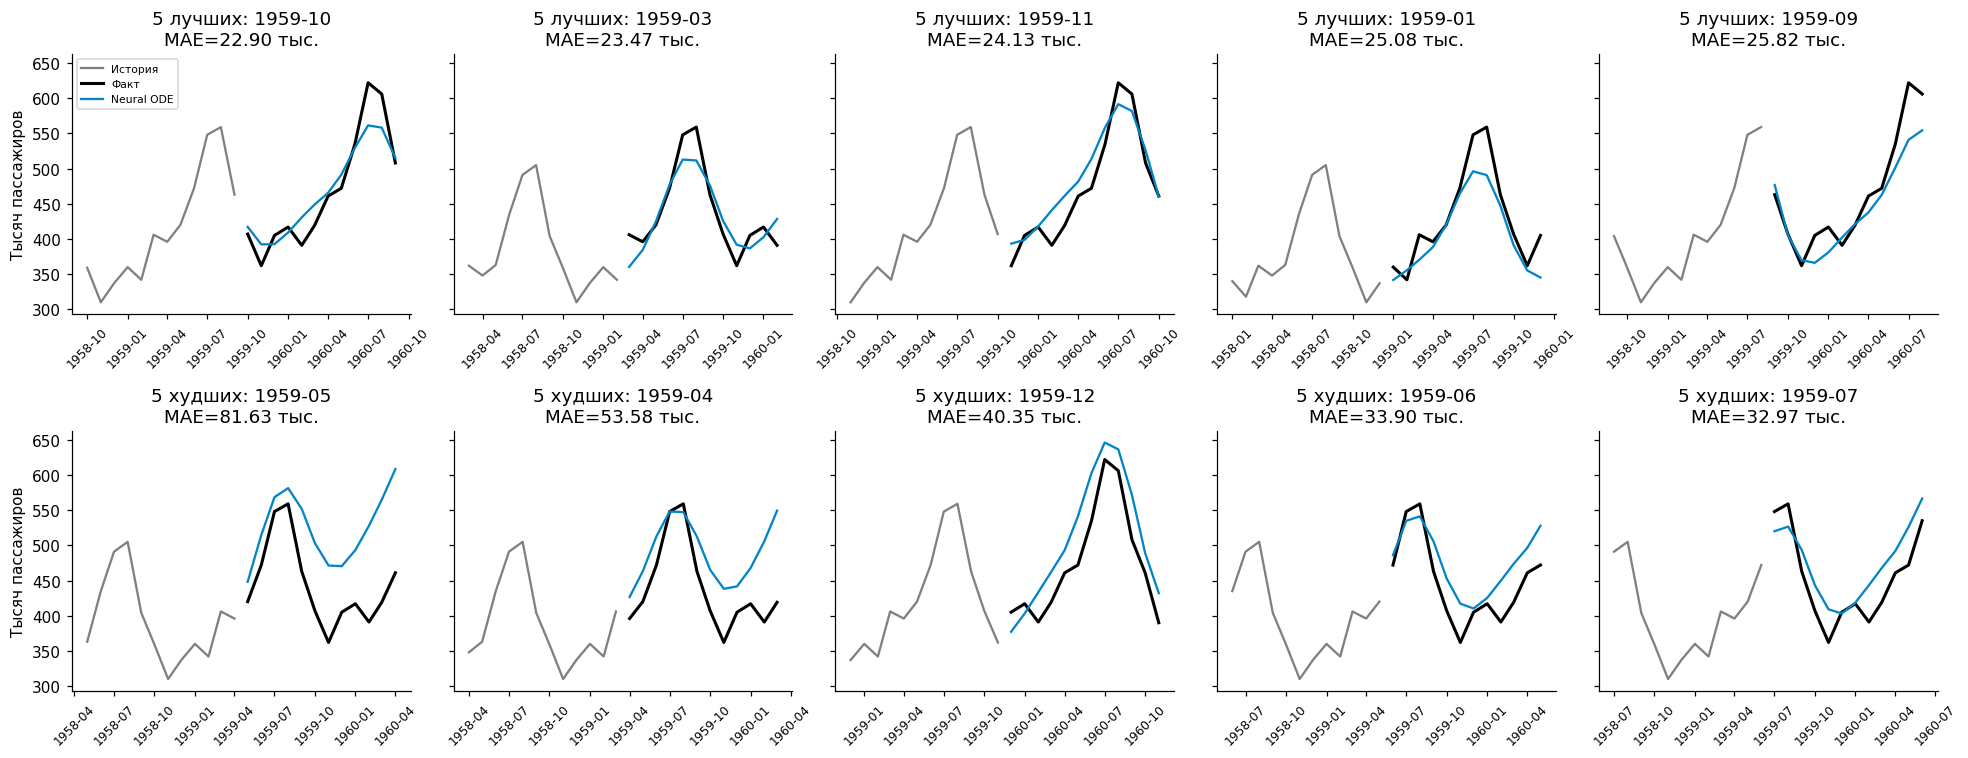

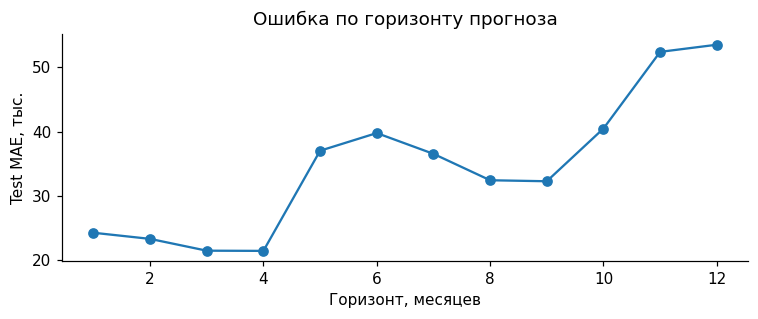

In [ ]:
@torch.no_grad()
def predict(x,p,**kwargs):
    return inverse(model(x,p,**kwargs))

def metrics(y,p):
    e = p-y
    return {'MAE':float(np.abs(e).mean()),'RMSE':float(np.sqrt(np.mean(e**2))),
            'MAPE_pct':float(np.mean(np.abs(e)/y)*100)}


rows=[]
for split,(x,y,p,o) in parts.items():
    for name,pred in {'Neural ODE':predict(x,p),}.items():
        rows.append({'split':split,'model':name,**metrics(inverse(y),pred)})

score = pd.DataFrame(rows)
print(score.round(3).to_string(index=False))
x,y,phase,origins = parts['test']
truth, pred = inverse(y), predict(x,phase)
window_mae = np.abs(pred-truth).mean(axis=1)
best_indices = np.argsort(window_mae)[:5]
worst_indices = np.argsort(window_mae)[-5:][::-1]
good = int(best_indices[0])
bad = int(worst_indices[0])

print('Пять лучших окон (по MAE):')
for i in best_indices:
    print(f'  {dates[origins[i]]:%Y-%m}: MAE={window_mae[i]:.2f} тыс.')

print('Пять худших окон (по MAE):')
for i in worst_indices:
    print(f'  {dates[origins[i]]:%Y-%m}: MAE={window_mae[i]:.2f} тыс.')

fig,axes=plt.subplots(2,5,figsize=(18,7),sharey=True)
for row,indices,title in [(0,best_indices,'5 лучших'),(1,worst_indices,'5 худших')]:
    for col,i in enumerate(indices):
        ax=axes[row,col]
        o=origins[i]
        ax.plot(dates[o-12:o],values[o-12:o],color='gray',label='История')
        ax.plot(dates[o:o+H],truth[i],color='black',lw=2,label='Факт')
        ax.plot(dates[o:o+H],pred[i],color='#0284c7',label='Neural ODE')
        ax.set_title(f'{title}: {dates[o]:%Y-%m}\nMAE={window_mae[i]:.2f} тыс.')
        ax.tick_params(axis='x',rotation=45,labelsize=8)
        if col==0:
            ax.set_ylabel('Тысяч пассажиров')
axes[0,0].legend(fontsize=7)
fig.tight_layout()
savefig('03_best_worst_test_examples')

fig,ax=plt.subplots(figsize=(7,3))
ax.plot(np.arange(1,13),np.abs(pred-truth).mean(axis=0),marker='o')
ax.set(xlabel='Горизонт, месяцев',ylabel='Test MAE, тыс.',title='Ошибка по горизонту прогноза')
savefig('04_horizon')

## Контролируемое нарушение входных данных
Меняем только историю test, сохраняя истинную цель: это повреждение измерений,
а не утверждение, что реальный пассажиропоток изменился без изменения будущего. White-box FGSM:
$$x_{adv}=x+\epsilon\operatorname{sign}(\nabla_x\mathcal L(x,y)).$$
Истинная цель используется атакующим для стресс-теста; она не передаётся
модели как признак. 
В исходных единицах изменение ограничено множителями $\exp(\pm\sigma\epsilon)$.
Нет переобучения или выбора параметров по атакованному test.
Проверяем сетку 0, 0.05, 0.10, 0.20;
Искажения строятся отдельно для каждого окна: это отдельные запросы прогноза,
а не единая согласованная подмена всего ряда. 

In [20]:
# FGSM-градиент считаем только по всем окнам test; train/validation не затрагиваем.
attack_x = x.detach().clone().requires_grad_(True)
attack_loss = (model(attack_x, phase) - y).square().mean()
grad = torch.autograd.grad(attack_loss, attack_x)[0].detach()

# Оцениваем всю test-часть для каждой величины возмущения.
eps_grid = [0.0, 0.05, 0.10, 0.20]
attack_rows = []
adversarial_predictions = {}
for eps in eps_grid:
    x_eps = x + eps * grad.sign()
    pred_eps = predict(x_eps, phase)
    adversarial_predictions[eps] = pred_eps
    attack_rows.append({'eps': eps, **metrics(truth, pred_eps)})

attack_scores = pd.DataFrame(attack_rows)
print('FGSM на всей test части:')
print(attack_scores.round(3).to_string(index=False))

# Сохраняем eps=0.10 для последующих графиков скрытых состояний и чувствительности.
EPS = 0.10
x_adv = x + EPS * grad.sign()
pred_adv = adversarial_predictions[EPS]
print(f'FGSM eps={EPS:.2f}: множители измерений от {np.exp(-sigma*EPS):.4f} до {np.exp(sigma*EPS):.4f}')

FGSM на всей test части:
 eps     MAE    RMSE  MAPE_pct
0.00  34.599  44.940     7.785
0.05  59.432  73.371    13.375
0.10  85.423 102.029    19.129
0.20 128.929 151.117    28.715
FGSM eps=0.10: множители измерений от 0.9672 до 1.0339


In [ ]:
# Change here
# Добавь пример с атакой для тех же 5 лучших и 5 худших примеров. На графике также должны быть кривые и без атаки

## Интерпретация 1 — траектории скрытого состояния
PCA обучается **только на траекториях train**. На общей проекции сравниваются
типичное окно, худшее окно и атакованная версия типичного. Дополнительно
измеряется расстояние между чистой и атакованной траекториями в полном
12-мерном пространстве. PCA показывает лишь часть геометрии; близость на
рисунке не доказывает идентичность состояний или причинный механизм.

Объяснённая дисперсия PCA: [0.42536926 0.2989861 ] сумма 0.72435534


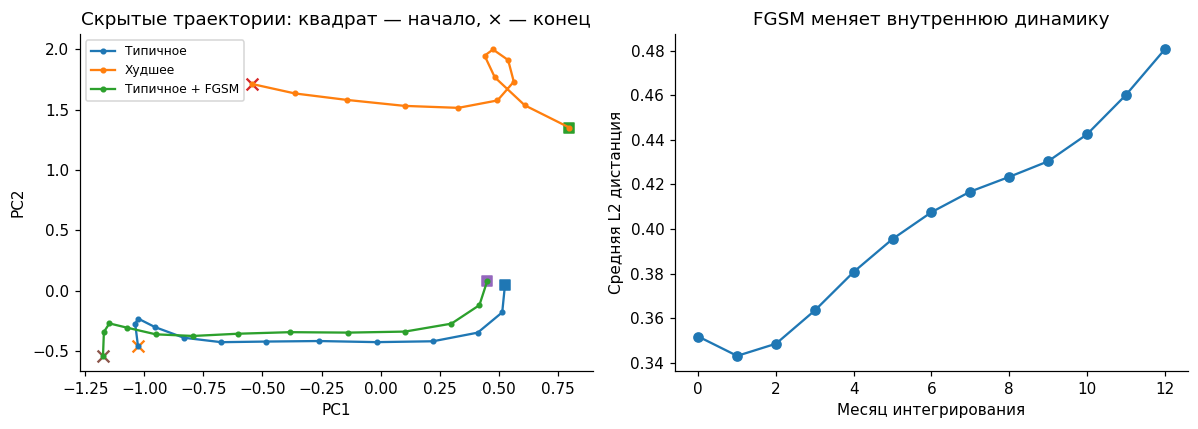

In [15]:
with torch.no_grad():
    _,train_h=model(xt,pt,trajectory=True)
    _,clean_h=model(x,phase,trajectory=True)
    _,adv_h=model(x_adv,phase,trajectory=True)
pca=PCA(n_components=2).fit(train_h.numpy().reshape(-1,12))
print('Объяснённая дисперсия PCA:',pca.explained_variance_ratio_, 'сумма',pca.explained_variance_ratio_.sum())
fig,axes=plt.subplots(1,2,figsize=(11,4))
for label,h in [('Типичное',clean_h[good]),('Худшее',clean_h[bad]),('Типичное + FGSM',adv_h[good])]:
    coords=pca.transform(h.numpy())
    axes[0].plot(coords[:,0],coords[:,1],marker='.',label=label)
    axes[0].scatter(*coords[0],marker='s',s=50)
    axes[0].scatter(*coords[-1],marker='x',s=60)
axes[0].set(xlabel='PC1',ylabel='PC2',title='Скрытые траектории: квадрат — начало, × — конец')
axes[0].legend(fontsize=8)
hidden_distance=torch.linalg.vector_norm(adv_h-clean_h,dim=2).numpy()
axes[1].plot(np.arange(13),hidden_distance.mean(axis=0),marker='o')
axes[1].set(xlabel='Месяц интегрирования',ylabel='Средняя L2 дистанция',title='FGSM меняет внутреннюю динамику')
savefig('06_hidden')

## Интерпретация 2 — чувствительность прогноза к истории
Для каждого из трёх объектов вычисляем
$S_j=\frac1{12}\sum_k|\partial\hat z_k/\partial x_j|$.
Это локальная чувствительность к небольшому изменению конкретного месяца,
а не причинная важность. Используем одинаковый масштаб оси для чистого
и атакованного входа. Для регрессии «типичное» означает медианную ошибку;
модель не выдаёт вероятностную уверенность.

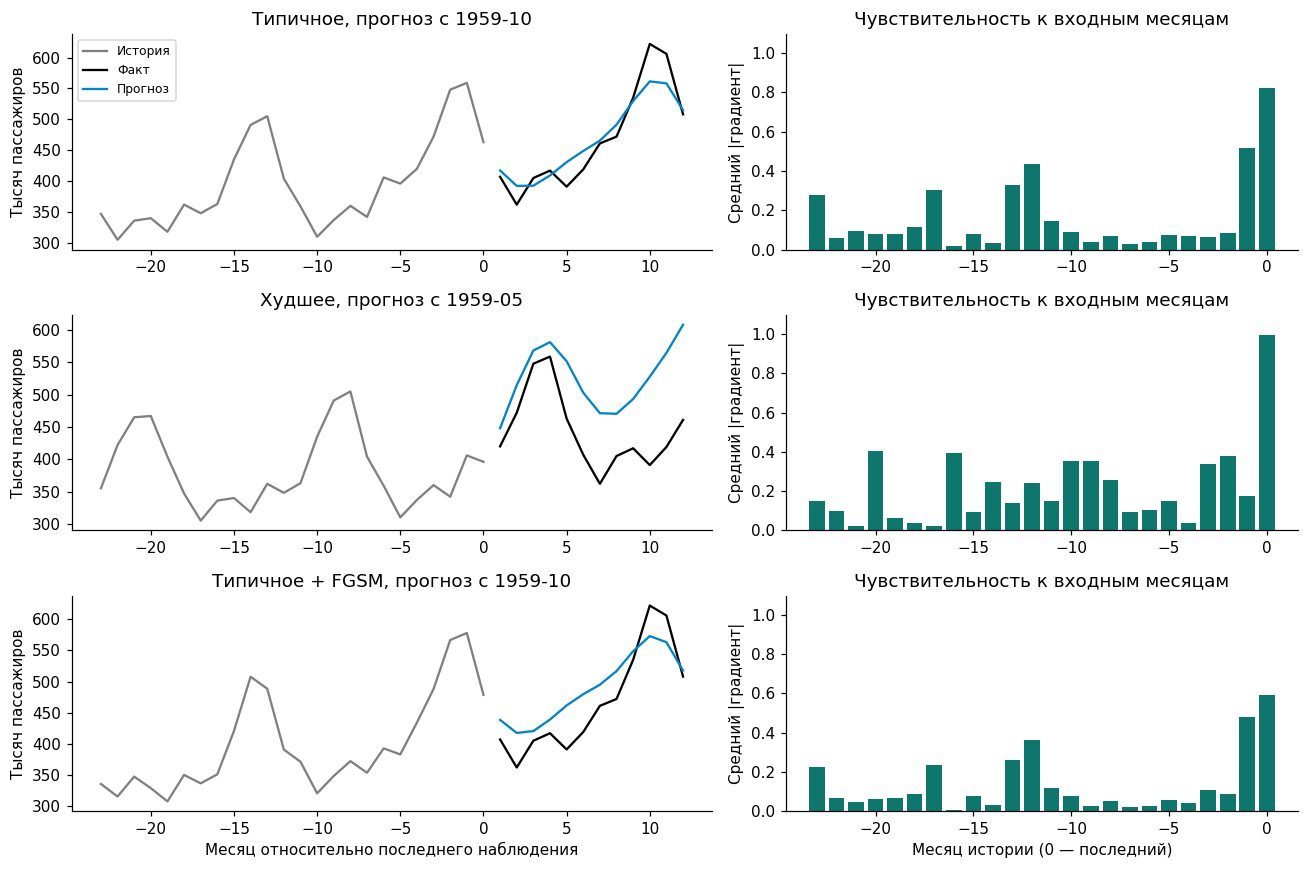

Наиболее чувствительные лаги типичного окна: [0, -1, -12, -13, -17]


In [14]:
cases=[('Типичное',x[good:good+1],phase[good:good+1],good),
       ('Худшее',x[bad:bad+1],phase[bad:bad+1],bad),
       ('Типичное + FGSM',x_adv[good:good+1],phase[good:good+1],good)]
sal=[]
for label,xx,pp,i in cases:
    xx=xx.detach().requires_grad_(True)
    jac=torch.autograd.functional.jacobian(lambda a:model(a,pp),xx)
    sal.append(jac[0,:,0,:].abs().mean(dim=0).numpy())
sal=np.stack(sal)
fig,axes=plt.subplots(3,2,figsize=(12,8),gridspec_kw={'width_ratios':[1.25,1]})
for row,(label,xx,pp,i) in enumerate(cases):
    o=origins[i]
    axes[row,0].plot(np.arange(-23,1),inverse(xx)[0],color='gray',label='История')
    axes[row,0].plot(np.arange(1,13),truth[i],color='black',label='Факт')
    axes[row,0].plot(np.arange(1,13),predict(xx,pp)[0],color='#0284c7',label='Прогноз')
    axes[row,0].set(title=f'{label}, прогноз с {dates[o]:%Y-%m}',ylabel='Тысяч пассажиров')
    axes[row,1].bar(np.arange(-23,1),sal[row],color='#0f766e')
    axes[row,1].set(ylim=(0,float(sal.max()*1.1)),ylabel='Средний |градиент|',title='Чувствительность к входным месяцам')
axes[0,0].legend(fontsize=8)
axes[-1,0].set_xlabel('Месяц относительно последнего наблюдения')
axes[-1,1].set_xlabel('Месяц истории (0 — последний)')
savefig('07_interpretation')
print('Наиболее чувствительные лаги типичного окна:', (np.argsort(sal[0])[-5:][::-1]-23).tolist())

## Результаты углублённой интерпретации

### Скрытые представления и механизм атаки

В типичном окне координаты 1, 9 и 6 дают наибольшие средние абсолютные вклады.
В худшем окне это 1, 2 и 10. Это номера координат данного экземпляра модели,
а не установленные факторы «тренд» или «сезонность». Например, на 12-м горизонте
в типичном окне координата 7 даёт отрицательный вклад −0,1801, частично
компенсируя положительные вклады. В худшем окне её вклад +0,0494.
Истории и календарные фазы этих окон различаются: такое сравнение описывает
разные решения, но само по себе не устанавливает причину ошибки.

Чистое и атакованное типичное окна имеют одну календарную фазу и одну цель,
поэтому их сравнение позволяет проследить эффект конкретного вмешательства.
После FGSM на 12-м горизонте отрицательный вклад координаты 7 ослабевает
с −0,1801 до −0,1267, а положительный вклад координаты 2 растёт с 0,0508 до 0,1059.
Изменения этих двух координат дают наибольшие средние положительные добавки
к прогнозу по горизонту. Остальные координаты тоже участвуют; полные значения
сохранены в hidden_contributions.csv.

На 12-м горизонте общий log-сдвиг равен **0.1274**:
**0.0334** приходится на прямое изменение опорного уровня,
**0.0941** — на изменение скрытой динамики.
В этой точной декомпозиции динамическая часть составляет **73.8% log-сдвига**.
Это не доля процентов изменения пассажиропотока: после exp суммарный прогноз
вырастает на **13.59%**.
MAE типичного окна меняется с **28.60** до
**68.61 тыс.**; эти числа относятся к одному окну,
а не к среднему по всему test (34,60 → 85,42 тыс.).

### Входные признаки и проверка объяснения

При увеличении последнего наблюдения типичного окна на 1% прогноз растёт
в среднем на **4,29 тыс.** Рост наблюдения с лагом −12 на 1% уменьшает прогноз
в среднем на **1,25 тыс.** Поэтому утверждение «годовая история важна» надо
дополнить направлением её влияния. Для выбранного слабого лага −19 среднее
абсолютное изменение составляет лишь **0,117 тыс.**

Для типичного окна при проверке трёх лагов в обоих направлениях (±1%)
максимальная ошибка градиентного приближения составляет **0.156 тыс.**
Это подтверждает локальное объяснение на проверенных вмешательствах, но не
гарантирует его точность при больших изменениях.

Особенно показательно худшее окно. Производная дальнего прогноза по последнему
наблюдению отрицательна: эластичность на 12-м горизонте **−1,568**.
Реальная прибавка 1% к этому наблюдению повышает прогноз первого месяца на
**2,24 тыс.**, но понижает прогноз двенадцатого на **10,26 тыс.**
Средняя ошибка локального приближения здесь 0,475 тыс. Такой разворот знака
не виден на старой диаграмме усреднённых модулей градиента. Это обнаруженное
поведение модели, а не доказательство, что именно оно вызвало исходную ошибку.

Для атакованного типичного окна положительная реакция последнего наблюдения
сохраняется: дополнительное +1% меняет дальний прогноз на **+5,01 тыс.**
Следовательно, повышение прогнозов после FGSM не обязательно сопровождается
ростом локальных градиентов: изменяется само состояние, из которого строится прогноз.


## Итоговые выводы и ограничения

Neural ODE обучена прогнозировать 12 месяцев AirPassengers по истории из 24 месяцев.
Единое нейронное векторное поле описывает скрытую динамику; RK4 интегрирует её,
линейное чтение формирует прогноз в каждом месяце. Годовая фаза задана явно.

Test MAE — 34,60 тыс., у сезонного baseline с ростом — 26,96 тыс. На маленьком
ряду архитектура не получила преимущества над сильным простым прогнозом.
FGSM ε=0,10 повышает среднюю test MAE до 85,42 тыс. (2,47×).

Углублённый анализ связывает изменение входа с конкретными изменениями
скрытых вкладов и выхода. Для типичного окна основная часть дальнего log-сдвига
при атаке проходит через скрытую динамику. Знаковый якобиан обнаруживает
противоположное влияние последнего наблюдения на ближний и дальний прогноз
худшего окна; вмешательство подтверждает этот эффект.

Ограничения: один seed, один короткий ряд, зависимые окна, локальность градиентного
анализа и зависимость скрытых вкладов от выбора координат. FGSM использует цель
как white-box стресс-тест и не измеряет вероятность реальной атаки. Интерпретация
объясняет вычисления модели, а не причинные закономерности пассажиропотока.

Практические направления: проверка обучения с искажениями истории, контроль
измерений, несколько seed и временных разбиений, сравнение с ETS/SARIMA и
более крупные наборы. Результативность этих мер здесь не проверена.
